# Exploration Notebook
## Letterboxd Dashboard
### Reid B.

# Import & Load 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ratings = pd.read_csv("data/ratings.csv")
diary = pd.read_csv("data/diary.csv")
watched = pd.read_csv("data/watched.csv")
watchlist = pd.read_csv("data/watchlist.csv")

for df in [ratings, diary, watched, watchlist]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    if 'year' in df.columns:
        df['year'] = df['year'].astype('Int64')
    if 'watched_date' in df.columns:
        df['watched_date'] = pd.to_datetime(diary['watched_date'], errors='coerce')

print(f"Ratings shape: {ratings.shape}")
print(f"Diary shape: {diary.shape}")
print(f"Watched shape: {watched.shape}")
print(f"Watchlist shape: {watchlist.shape}")

Ratings shape: (761, 5)
Diary shape: (906, 8)
Watched shape: (1230, 4)
Watchlist shape: (911, 4)


In [2]:
# Basic stats
print(f"Total films rated: {len(ratings)}")
print(f"Diary entries: {len(diary)}")
ratings["rating"].describe()

Total films rated: 761
Diary entries: 906


count    761.000000
mean       3.420499
std        0.988380
min        0.500000
25%        3.000000
50%        3.500000
75%        4.000000
max        5.000000
Name: rating, dtype: float64

In [3]:
# What's my most watched year of film?
ratings["year"].value_counts().head(10)

year
2023    74
2025    69
2024    67
2022    31
2017    29
2019    27
2014    24
2021    19
2013    18
2007    16
Name: count, dtype: Int64

In [4]:
# How many films do I log per month?
diary["date"] = pd.to_datetime(diary["date"])
diary_by_month = diary.groupby(diary["date"].dt.to_period("M")).size()
print(diary_by_month.head())

date
2022-09     6
2022-10     1
2022-11     3
2022-12    13
2023-01    14
Freq: M, dtype: int64


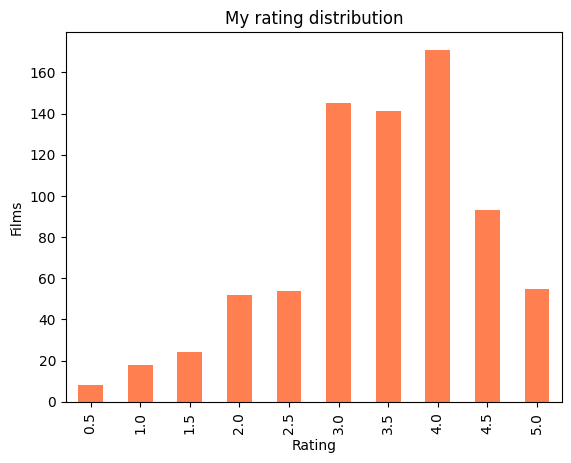

In [5]:
rating_counts = ratings["rating"].value_counts().sort_index()
rating_counts.plot(kind="bar", color="coral")
plt.title("My rating distribution")
plt.xlabel("Rating")
plt.ylabel("Films")
plt.show()

# Header stats (All-time)
1. count of films
2. hours watched
3. directors
4. countries
5. longest streak
6. 2+ film days

note: later on, customize to selected year.

In [6]:
# films watched 
films_watched = len(watched)
print(f'Films watched: {films_watched}')

Films watched: 1230


In [7]:
# 2-4... use api
# hours
# directors
# countries

In [8]:
# streak (days)
watch_dates = (
    diary.watched_date.dt.date.drop_duplicates().sort_values().reset_index(drop=True)
)

longest_streak = 1
current_streak = 1

for i in range(1, len(watch_dates)):
    gap = (watch_dates[i] - watch_dates[i - 1]).days
    if gap == 1:
        current_streak += 1
        longest_streak = max(longest_streak, current_streak)
    else:
        current_streak = 1

print(f'Longest streak: {longest_streak} consecutive days')

Longest streak: 20 consecutive days


In [9]:
# Streak (weeks)
watch_weeks = (
    diary['watched_date'].dt.to_period('W').drop_duplicates().sort_values().reset_index(drop=True)
)

longest_week_streak = 1
current_week_streak = 1

for i in range(1, len(watch_weeks)):
    gap = watch_weeks[i].week - watch_weeks[i - 1].week
    year_gap = watch_weeks[i].year - watch_weeks[i - 1].year
    
    is_consecutive = (gap == 1) or (year_gap == 1 and gap < 0)
    
    if is_consecutive:
        current_week_streak += 1
        longest_week_streak = max(longest_week_streak, current_week_streak)
    else:
        current_week_streak = 1

print(f'Longest weekly streak: {longest_week_streak} consecutive weeks')

Longest weekly streak: 33 consecutive weeks


In [10]:
films_per_day = diary.groupby(diary['watched_date'].dt.date)['name'].count()
multi_film_days = (films_per_day >= 2).sum()

print(f'Days with 2+ films: {multi_film_days}')
print()
print('Films per day:')
print(films_per_day.value_counts().sort_index())

Days with 2+ films: 192

Films per day:
name
1    424
2    123
3     48
4     14
5      6
6      1
Name: count, dtype: int64


# Top films

## by year


In [11]:
# by year - film (watched)
watched_year = watched.groupby("year")["name"].count()
# by year - rating
ratings_year = ratings.groupby("year")["name"].count()
# by year - diary
diary['log_year'] = diary['watched_date'].dt.year
diary_year = diary.groupby("log_year")["name"].count()

print(watched_year.head())
print(ratings_year.head())
print(diary_year.head())

year
1902    1
1922    1
1924    1
1928    1
1931    1
Name: name, dtype: int64
year
1924    1
1928    1
1931    1
1941    2
1948    1
Name: name, dtype: int64
log_year
2022     23
2023    278
2024    217
2025    274
2026    114
Name: name, dtype: int64


In [12]:
year_ct = ratings.groupby("year")["rating"].count().sort_values(ascending=False)
year_avg = ratings.groupby("year")["rating"].mean().sort_values(ascending=False)

print(year_ct.head())
print(year_avg.head())

year
2023    74
2025    69
2024    67
2022    31
2017    29
Name: rating, dtype: int64
year
1924    5.00
1952    5.00
1966    5.00
1960    5.00
1975    4.75
Name: rating, dtype: float64


## highest rated decades

In [13]:
# by decade
ratings['decade'] = (ratings['year'] // 10 * 10).astype(str) + 's'
decade_ct = ratings.groupby("decade")["rating"].count().sort_values(ascending=False)
decade_avg = round(ratings.groupby("decade")["rating"].mean().sort_values(ascending=False), 2)

# Filter to decades with at least 20 films
min_films = 20
decade_ct = decade_ct[decade_ct >= min_films]
decade_avg = decade_avg[decade_avg.index.isin(decade_ct.index)]

print(decade_ct.head())
print(decade_avg.head())

decade
2020s    288
2010s    182
2000s    117
1990s     76
1980s     50
Name: rating, dtype: int64
decade
1970s    3.94
1980s    3.86
2000s    3.62
1990s    3.62
2010s    3.26
Name: rating, dtype: float64


## most watched
## rated higher than avg
## rated lower than avg

In [14]:
# most watched
diary.groupby('name').size().sort_values(ascending=False).head(20)

name
Scott Pilgrim vs. the World              8
Frances Ha                               6
Mulholland Drive                         4
Superman                                 4
Past Lives                               4
Blue Velvet                              4
Lady Bird                                4
Fargo                                    3
Rudolph the Red-Nosed Reindeer           3
The Perks of Being a Wallflower          3
Scott Pilgrim Takes Off                  3
Dune                                     3
Princess Mononoke                        3
The Wind Rises                           3
Hot Rod                                  3
Die Hard                                 3
National Lampoon's Christmas Vacation    3
Spirited Away                            3
Planes, Trains and Automobiles           3
The Worst Person in the World            3
dtype: int64

## TBD for API
genres, countries, & languages
themes
list progress
collections

top cast
most watched, highest rated

top directors
most watched, highest rated

crew & studios
most watched, highest rated

world map

etc.


In [15]:
# Unrated watched films
watched_not_rated = set(watched["name"]) - set(ratings["name"])
print(f"Films watched but not rated: {len(watched_not_rated)}")

Films watched but not rated: 463
